In [13]:
import pandas as pd
import numpy as np
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
tips = pd.read_csv(url)
tips['tip_pct'] = (tips['tip'] / tips['total_bill'] * 100).round(1)
print(f"tips: {tips.shape[0]} wierszy, {tips.shape[1]} kolumn")

tips: 244 wierszy, 8 kolumn


In [2]:
lotniska = pd.DataFrame({
 'miasto': ['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław', 'Katowice',
 'Poznań', 'Rzeszów', 'Łódź', 'Szczecin', 'Bydgoszcz'],
 'kod': ['WAW', 'KRK', 'GDN', 'WRO', 'KTW',
 'POZ', 'RZE', 'LCJ', 'SZZ', 'BZG'],
 'pasazerowie_mln': [18.9, 9.3, 5.7, 3.8, 5.4,
 2.6, 0.9, 0.3, 0.6, 0.4],
 'linie': [85, 42, 35, 28, 32, 22, 12, 5, 8, 6],
 'region': ['Mazowieckie', 'Małopolskie', 'Pomorskie', 'Dolnośląskie',
'Śląskie',
 'Wielkopolskie', 'Podkarpackie', 'Łódzkie', 'Zachodniopomorskie',
'Kujawsko-Pomorskie']
})
lotniska.index = lotniska['kod']
print(lotniska[['miasto', 'pasazerowie_mln', 'linie', 'region']])

        miasto  pasazerowie_mln  linie              region
kod                                                       
WAW   Warszawa             18.9     85         Mazowieckie
KRK     Kraków              9.3     42         Małopolskie
GDN     Gdańsk              5.7     35           Pomorskie
WRO    Wrocław              3.8     28        Dolnośląskie
KTW   Katowice              5.4     32             Śląskie
POZ     Poznań              2.6     22       Wielkopolskie
RZE    Rzeszów              0.9     12        Podkarpackie
LCJ       Łódź              0.3      5             Łódzkie
SZZ   Szczecin              0.6      8  Zachodniopomorskie
BZG  Bydgoszcz              0.4      6  Kujawsko-Pomorskie


In [3]:
print(lotniska.iloc[:3])
print(lotniska.iloc[4:8, [0, 2]])
print(lotniska.iloc[::-2])

       miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
GDN    Gdańsk  GDN              5.7     35    Pomorskie
       miasto  pasazerowie_mln
kod                           
KTW  Katowice              5.4
POZ    Poznań              2.6
RZE   Rzeszów              0.9
LCJ      Łódź              0.3
        miasto  kod  pasazerowie_mln  linie              region
kod                                                            
BZG  Bydgoszcz  BZG              0.4      6  Kujawsko-Pomorskie
LCJ       Łódź  LCJ              0.3      5             Łódzkie
POZ     Poznań  POZ              2.6     22       Wielkopolskie
WRO    Wrocław  WRO              3.8     28        Dolnośląskie
KRK     Kraków  KRK              9.3     42         Małopolskie


In [4]:
print(lotniska.loc['KRK'])
print(lotniska.loc[['WAW', 'GDN', 'KTW'], ['miasto', 'linie']])
print(lotniska.loc[lotniska['pasazerowie_mln'] > 5])
print(lotniska.loc[lotniska['linie'] < 20, ['miasto', 'region']])

miasto                  Kraków
kod                        KRK
pasazerowie_mln            9.3
linie                       42
region             Małopolskie
Name: KRK, dtype: object
       miasto  linie
kod                 
WAW  Warszawa     85
GDN    Gdańsk     35
KTW  Katowice     32
       miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
GDN    Gdańsk  GDN              5.7     35    Pomorskie
KTW  Katowice  KTW              5.4     32      Śląskie
        miasto              region
kod                               
RZE    Rzeszów        Podkarpackie
LCJ       Łódź             Łódzkie
SZZ   Szczecin  Zachodniopomorskie
BZG  Bydgoszcz  Kujawsko-Pomorskie


In [8]:
print(lotniska[lotniska['region'].str.startswith('M')].shape[0])
lotniska['oblozenie'] = lotniska['pasazerowie_mln'] / lotniska['linie'] * 1000000
print(lotniska.nlargest(3, 'oblozenie')[['miasto', 'oblozenie']])

2
       miasto      oblozenie
kod                         
WAW  Warszawa  222352.941176
KRK    Kraków  221428.571429
KTW  Katowice  168750.000000


In [14]:
print(tips[tips['day'] == 'Fri'].shape[0])
print(tips[tips['size'] == 1].shape[0])
print(tips[tips['size'] == 6].shape[0])
print(tips[tips['sex'] == 'Female']['total_bill'].max())

19
4
4
44.3


In [15]:
print(tips[(tips['sex'] == 'Male') & (tips['smoker'] == 'No') & (tips['time'] == 'Dinner') & (tips['day'].isin(['Sat', 'Sun']))].shape[0])
print(tips[(tips['size'] >= 4) & (tips['day'] == 'Thur')]['total_bill'].mean())
print(tips[(tips['tip'] / tips['total_bill'] > 0.25) & (tips['total_bill'] < 10)].shape[0])

75
31.343333333333323
4


In [16]:
print(tips[tips['day'].isin(['Sat', 'Sun']) & tips['total_bill'].between(15, 30)].shape[0])
print(tips.query("day in ['Sat', 'Sun'] and total_bill >= 15 and total_bill <= 30").shape[0])
srednia = tips['total_bill'].mean()
print(tips.query("sex == 'Male' and smoker == 'No' and time == 'Dinner' and total_bill > @srednia").shape[0])

93
93
33


In [5]:
import pandas as pd
import numpy as np

filmy = pd.DataFrame({
    'tytul': ['Incepcja', 'Parasite', 'Avengers: Endgame', 'Joker', 'Coco',
              'Get Out', 'Dune', 'Whiplash', 'Mad Max: Fury Road', 'Spider-Man: No Way Home',
              'The Batman', 'Everything Everywhere', 'Oppenheimer', 'Barbie', 'La La Land',
              'Blade Runner 2049', 'Knives Out', '1917', 'Jojo Rabbit', 'Midsommar'],
    'rok': [2010, 2019, 2019, 2019, 2017,
            2017, 2021, 2014, 2015, 2021,
            2022, 2022, 2023, 2023, 2016,
            2017, 2019, 2019, 2019, 2019],
    'gatunek': ['Sci-Fi', 'Thriller', 'Akcja', 'Dramat', 'Animacja',
                'Horror', 'Sci-Fi', 'Dramat', 'Akcja', 'Akcja',
                'Akcja', 'Sci-Fi', 'Dramat', 'Komedia', 'Musical',
                'Sci-Fi', 'Kryminał', 'Wojenny', 'Komedia', 'Horror'],
    'budzet_mln': [160, 11, 356, 55, 175,
                   4.5, 165, 3.3, 150, 200,
                   185, 25, 100, 145, 30,
                   150, 40, 95, 14, 9],
    'przychod_mln': [836, 258, 2798, 1074, 807,
                     255, 407, 49, 380, 1916,
                     771, 141, 952, 1442, 447,
                     259, 311, 384, 90, 48],
    'ocena_imdb': [8.8, 8.5, 8.4, 8.4, 8.4,
                   7.7, 8.0, 8.5, 8.1, 8.2,
                   7.8, 7.8, 8.3, 6.8, 8.0,
                   8.0, 7.9, 8.3, 7.9, 7.1]
})

filmy['roi'] = (filmy['przychod_mln'] / filmy['budzet_mln']).round(1)

print(filmy.nlargest(5, 'przychod_mln')[['tytul', 'przychod_mln']])
print(filmy.nlargest(5, 'roi')[['tytul', 'roi']])
print(filmy.nlargest(5, 'ocena_imdb')[['tytul', 'ocena_imdb']])
print(filmy[filmy['budzet_mln'] < 15][['tytul', 'budzet_mln', 'przychod_mln']])

                      tytul  przychod_mln
2         Avengers: Endgame          2798
9   Spider-Man: No Way Home          1916
13                   Barbie          1442
3                     Joker          1074
12              Oppenheimer           952
         tytul   roi
5      Get Out  56.7
1     Parasite  23.5
3        Joker  19.5
14  La La Land  14.9
7     Whiplash  14.8
               tytul  ocena_imdb
0           Incepcja         8.8
1           Parasite         8.5
7           Whiplash         8.5
2  Avengers: Endgame         8.4
3              Joker         8.4
          tytul  budzet_mln  przychod_mln
1      Parasite        11.0           258
5       Get Out         4.5           255
7      Whiplash         3.3            49
18  Jojo Rabbit        14.0            90
19    Midsommar         9.0            48


In [6]:
print(filmy[filmy['gatunek'] == 'Akcja'].shape[0])
print(filmy[filmy['gatunek'] == 'Akcja']['roi'].mean())

print(filmy[(filmy['ocena_imdb'] >= 8.0) & (filmy['budzet_mln'] < 50)][['tytul', 'ocena_imdb', 'budzet_mln']])

for gatunek in filmy['gatunek'].unique():
    sredni_roi = filmy[filmy['gatunek'] == gatunek]['roi'].mean()
    print(gatunek, sredni_roi)

print(filmy[(filmy['rok'] >= 2019) & (filmy['rok'] <= 2023) & (filmy['roi'] > 5)][['tytul', 'rok', 'roi']])

4
6.05
         tytul  ocena_imdb  budzet_mln
1     Parasite         8.5        11.0
7     Whiplash         8.5         3.3
14  La La Land         8.0        30.0
Sci-Fi 3.75
Thriller 23.5
Akcja 6.05
Dramat 14.6
Animacja 4.6
Horror 31.0
Komedia 8.15
Musical 14.9
Kryminał 7.8
Wojenny 4.0
                      tytul   rok   roi
1                  Parasite  2019  23.5
2         Avengers: Endgame  2019   7.9
3                     Joker  2019  19.5
9   Spider-Man: No Way Home  2021   9.6
11    Everything Everywhere  2022   5.6
12              Oppenheimer  2023   9.5
13                   Barbie  2023   9.9
16               Knives Out  2019   7.8
18              Jojo Rabbit  2019   6.4
19                Midsommar  2019   5.3


In [7]:
wynik = (filmy[filmy['ocena_imdb'] >= 7.5]
         .nlargest(3, 'roi')
         [['tytul', 'gatunek', 'roi', 'ocena_imdb']])

print(wynik)

      tytul   gatunek   roi  ocena_imdb
5   Get Out    Horror  56.7         7.7
1  Parasite  Thriller  23.5         8.5
3     Joker    Dramat  19.5         8.4


In [8]:
filmy['segment'] = np.select(
    [filmy['roi'] > 10, filmy['roi'] > 3],
    ['Hit', 'Zyskowny'],
    default='Przeciętny'
)

print(filmy['segment'].value_counts())
print(filmy.groupby('segment')['ocena_imdb'].mean().round(1))

segment
Zyskowny      12
Hit            5
Przeciętny     3
Name: count, dtype: int64
segment
Hit           8.2
Przeciętny    8.0
Zyskowny      8.0
Name: ocena_imdb, dtype: float64


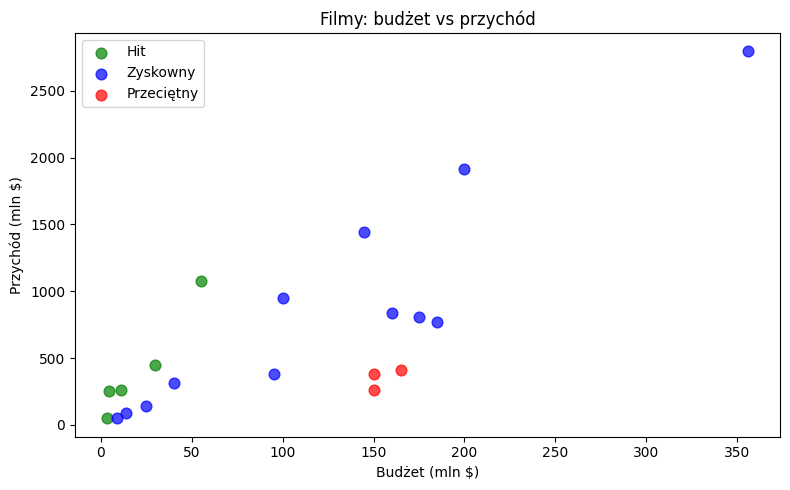

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

kolory = {'Hit': 'green', 'Zyskowny': 'blue', 'Przeciętny': 'red'}

for seg, kolor in kolory.items():
    dane = filmy[filmy['segment'] == seg]
    ax.scatter(dane['budzet_mln'], dane['przychod_mln'],
               c=kolor, label=seg, s=60, alpha=0.7)

ax.set_xlabel('Budżet (mln $)')
ax.set_ylabel('Przychód (mln $)')
ax.set_title('Filmy: budżet vs przychód')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# REKOMENDACJA:
# Dane pokazują że najlepszy zwrot dają tanie filmy z niskim budżetem jak Get Out (4.5 mln$, ROI 56.7) czy Parasite (11 mln$, ROI 23.5).
# Firma powinna stawiać na tanie perełki z dobrymi ocenami zamiast drogie blockbustery, bo ryzyko jest mniejsze a zwrot wyższy.